In [1]:
# setting root at top

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

# Base Model with 64x64 Image and 4 Conv Blocks
# Using OverSampled high-alert and 0.0075 Learning Rate

### Import libraries
* `torch`
* `datasets` and `transforms` from `torchvision` for data Loading.
* `DataLoader` and `WeightedRandomSampler` from `torch.utils.data` for Batching and using data in model.
* `BaseModel` from `architectures.BaseModel.py`
* `pandas` as `pd`
* `matplotlib.pyplot` as `plt`
* `seaborn` as sns
* `trainer` from `modules.TrainTest`
* `oversampler` from `modules.OverSampler`

In [2]:
# training and architecture
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from architectures.BaseModel import BaseModel

# visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#trainer and tester modules
from modules.TrainTest import trainer
from modules.OverSampler import oversampler

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [ ]:
train_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ]
)

train_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/train",
    transform=train_transform
)

sampler = oversampler(
    dataset=train_dataset,
    oversample_rate= 8
)


In [4]:

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    sampler=sampler
)

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [5]:
valid_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ]
)

valid_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/valid",
    transform=valid_transform
)

valid_dataloader = DataLoader(
    dataset=valid_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

### Use Model for training
Initialize model using 
* `conv_layers = 4`, 
* `initial_output_channel = 8` 
* `initial_image_size = 64`

In [6]:
model = BaseModel(conv_layers=4, initial_output_channel=8, initial_image_size=64).to("cuda")

In [7]:
metrics = trainer(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=valid_dataloader,
    epoch=20,
    lr=0.0075,
    print_on=5,
    save_dir="../models/base_img64_c4_lr_0.0075_os/",
    save_checkpoints=10,
    checkpoint_name="base_64x64_train_0_"
)

Epoch 5/20 | Train Loss: 0.2932 | Validation Loss: 0.8936
Epoch 10/20 | Train Loss: 0.0557 | Validation Loss: 1.4022
Epoch 15/20 | Train Loss: 0.0017 | Validation Loss: 2.3439
Epoch 20/20 | Train Loss: 0.0008 | Validation Loss: 2.6520


## Visualize

Convert metrics to a pd.DataFrame and add epoch column for visualization.

In [8]:
metrics = pd.DataFrame(metrics)
epochs = [i+1 for i  in range(len(metrics))]
metrics["epoch"] = epochs

In [9]:
metrics.head(10)

,epoch,training_loss,training_accuracy,training_precision,training_recall,training_f1,test_loss,test_accuracy,test_precision,test_recall,test_f1
0,1,1.097906,0.350205,0.350928,0.349527,0.334598,1.091123,0.521389,0.173796,0.333333,0.228471
1,2,1.054354,0.458470,0.457615,0.458353,0.444888,0.963596,0.501059,0.456527,0.536620,0.445461
2,3,0.826913,0.621847,0.618461,0.621909,0.618552,0.861808,0.595510,0.519106,0.558813,0.511000
3,4,0.474625,0.800057,0.797401,0.800134,0.798097,0.800154,0.649725,0.553292,0.600329,0.566551
4,5,0.293226,0.877983,0.876862,0.877654,0.877097,0.893561,0.684879,0.625243,0.575462,0.582645
5,6,0.207459,0.916211,0.915866,0.916031,0.915904,0.883233,0.713257,0.629856,0.599140,0.610846
6,7,0.153976,0.939321,0.939400,0.939475,0.939408,1.022874,0.729352,0.662500,0.591707,0.611829
7,8,0.114711,0.955408,0.955334,0.955391,0.955349,1.155907,0.734858,0.656288,0.596153,0.615680
8,9,0.081638,0.969205,0.969158,0.969202,0.969172,1.445560,0.727658,0.682283,0.573009,0.591774
9,10,0.055713,0.979747,0.979708,0.979709,0.979704,1.402177,0.744176,0.660960,0.603968,0.621760


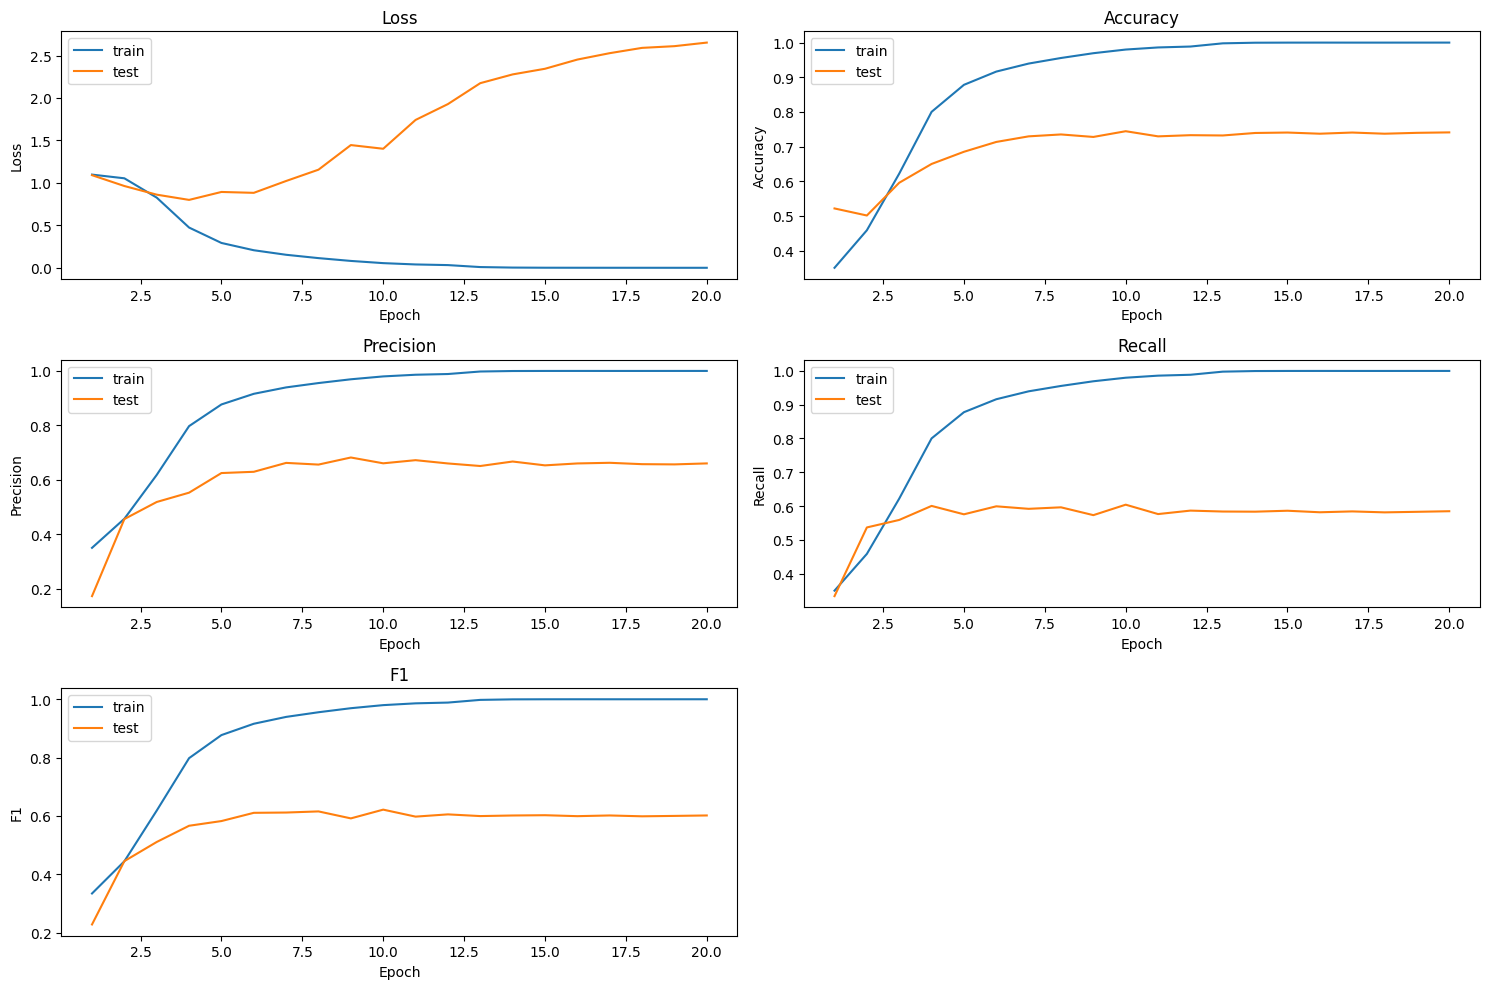

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.flatten()

to_viz = [
    "loss",
    "accuracy",
    "precision",
    "recall",
    "f1"
]

for i, metric in enumerate(to_viz):

    ax = axes[i]

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"training_{metric}",
        ax=ax,
        label="train"
    )

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"valid_{metric}",
        ax=ax,
        label="valid"
    )

    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())

# Hide unused subplot (6th slot)
axes[-1].axis("off")

plt.tight_layout()
plt.show()